# 03: Backdoor Adjustment and Confounding

We work through the most common observational causal design: estimating a treatment effect after adjusting for observed common causes. The key idea is the **backdoor path**. A backdoor path is a noncausal path from treatment to outcome that starts by going backward into a common cause.

We will build a dataset where treatment assignment is confounded, show why the naive comparison is biased, use the causal graph to choose an adjustment set, estimate the effect with DoWhy, and then study failure cases: partial adjustment, bad controls, colliders, and unobserved confounding.

## Learning Goals

By the end, you should be able to:

- Define confounding in terms of common causes and backdoor paths.
- Explain why treated and untreated groups can differ even before treatment.
- Identify a valid adjustment set for a total-effect question.
- Estimate the same effect with manual regression and DoWhy.
- Recognize partial adjustment, mediator adjustment, collider adjustment, and unobserved confounding as different failure modes.
- Write a clear backdoor-adjustment summary with assumptions and limitations.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Backdoor Adjustment And Confounding**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, or anomaly indicators are named to mirror applied causal workflows rather than abstract textbook variables. The experiment centers on confounding and adjustment. The comparison of naive and adjusted estimates is the main diagnostic, more than a software call.

The simulation is not meant to make the problem easy. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

For binary treatment, the average treatment effect is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Under conditional exchangeability, positivity, and consistency,

$$
\tau=\mathbb{E}_X\left[\mathbb{E}(Y\mid D=1,X)-\mathbb{E}(Y\mid D=0,X)\right].
$$

Matching, regression, and weighting are different computational routes to this adjusted contrast.





## Tutorial Workflow

### The Backdoor Idea in One Picture

Suppose `A` is treatment and `Y` is outcome. If a pre-treatment variable `C` causes both `A` and `Y`, then there is a path:

> `A <- C -> Y`

That path creates a relationship between treatment and outcome even if treatment had no causal effect. Backdoor adjustment tries to block such paths by comparing treated and untreated units that are similar in `C`.

The goal is to control for the right pre-treatment common causes.

#### Setup

This setup cell imports the packages used in the notebook, creates output folders, fixes a random seed, and suppresses known third-party compatibility warnings. It follows the same structure as the earlier DoWhy tutorials so students can focus on the causal content.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import platform
import sys
import warnings

START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"

for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__

    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise

    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.formula.api as smf

import dowhy
from dowhy import CausalModel

RANDOM_SEED = 23
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Python executable: /home/apex/Documents/portfolio/.venv/bin/python
Python version: 3.11.15
DoWhy version: 0.12
Notebook directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy
Output directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy/outputs


The notebook is ready if this step prints a DoWhy version. All outputs from this lesson use a `03_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### The Causal Question

We will use a product-style worked example. A platform exposes some users to a feature, and we want to know whether the exposure increases future user value.

The causal question is:

> What is the total average effect of `feature_exposure` on `weekly_value`?

The word **total** means we include all causal pathways from exposure to weekly value, including pathways through post-exposure activity.

### Roles and Timing

Backdoor adjustment depends heavily on timing. This table lists each variable, when it is measured, and whether it is appropriate to adjust for when estimating the total effect.

| variable | role | timing | total_effect_adjustment_guidance |
| --- | --- | --- | --- |
| feature_exposure | treatment | treatment time | treatment, not a control |
| weekly_value | outcome | future outcome window | outcome, not a control |
| user_engagement | observed confounder | pre-treatment | adjust |
| prior_sessions | observed confounder | pre-treatment | adjust |
| account_age_weeks | observed confounder | pre-treatment | adjust |
| baseline_value | observed confounder | pre-treatment | adjust |
| post_exposure_activity | mediator / bad control for total effect | post-treatment | do not adjust for total effect |
| support_ticket | collider / bad control | post-treatment | do not adjust |
| treatment_probability | simulation diagnostic | known only because this is simulated | do not use as a real observed column |


The pre-treatment common causes are the backdoor adjustment variables. The mediator and collider are useful for learning, but they should not be included as controls for the total effect.

#### Create a Confounded Dataset

The code below simulates data where the treatment effect is known. Treatment assignment depends on baseline engagement, previous sessions, account age, and baseline value. Those same variables also affect the outcome, so the naive exposed-versus-unexposed comparison will be biased.

The outcome also includes a mediated pathway through `post_exposure_activity`. That lets us show why controlling for a post-treatment mediator changes the estimand.

In [2]:
# Define reusable helpers for the Create A Confounded Dataset section.
def make_backdoor_data(n=5_000, seed=23):
    """
    Idea: Construct the backdoor data used in the Create A Confounded Dataset section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, truth.
    """
    local_rng = np.random.default_rng(seed)

    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_sessions = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.25 * user_engagement), size=n),
        0,
        30,
    )
    account_age_weeks = local_rng.gamma(shape=2.0, scale=4.0, size=n)
    baseline_value = (
        2.0
        + 1.10 * user_engagement
        + 0.060 * prior_sessions
        + 0.025 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    treatment_logit = (
        -0.70
        + 0.80 * user_engagement
        + 0.040 * prior_sessions
        + 0.180 * baseline_value
        + 0.020 * account_age_weeks
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)

    direct_effect = 1.80
    exposure_to_activity = 0.80
    activity_to_outcome = 0.50
    true_total_effect = direct_effect + exposure_to_activity * activity_to_outcome

    post_exposure_activity = (
        exposure_to_activity * feature_exposure
        + 0.70 * user_engagement
        + 0.030 * prior_sessions
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    weekly_value = (
        4.0
        + direct_effect * feature_exposure
        + activity_to_outcome * post_exposure_activity
        + 1.20 * user_engagement
        + 0.060 * prior_sessions
        + 0.030 * account_age_weeks
        + 0.550 * baseline_value
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    support_ticket_logit = -0.80 + 3.00 * feature_exposure - 0.50 * weekly_value + local_rng.normal(
        loc=0.0,
        scale=0.30,
        size=n,
    )
    support_ticket = local_rng.binomial(n=1, p=1 / (1 + np.exp(-support_ticket_logit)), size=n)

    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_sessions": prior_sessions,
            "account_age_weeks": account_age_weeks,
            "baseline_value": baseline_value,
            "post_exposure_activity": post_exposure_activity,
            "support_ticket": support_ticket,
            "treatment_probability": treatment_probability,
        }
    )

    truth = {
        "direct_effect": direct_effect,
        "exposure_to_activity": exposure_to_activity,
        "activity_to_outcome": activity_to_outcome,
        "true_total_effect": true_total_effect,
    }
    return df, truth

backdoor_df, truth = make_backdoor_data()
backdoor_df.to_csv(TABLE_DIR / "03_backdoor_teaching_dataset.csv", index=False)

print(f"Rows: {len(backdoor_df):,}")
print(f"Known direct effect: {truth['direct_effect']:.4f}")
print(f"Known mediated component: {truth['exposure_to_activity'] * truth['activity_to_outcome']:.4f}")
print(f"Known total effect: {truth['true_total_effect']:.4f}")
backdoor_df.head()


Rows: 5,000
Known direct effect: 1.8000
Known mediated component: 0.4000
Known total effect: 2.2000


,feature_exposure,weekly_value,user_engagement,prior_sessions,account_age_weeks,baseline_value,post_exposure_activity,support_ticket,treatment_probability
0,1,9.413987,0.553261,1,7.155994,3.637375,1.278976,0,0.641172
1,1,10.329205,0.217601,2,21.010390,3.269387,2.433627,0,0.637095
2,1,7.837427,-0.057990,3,7.334888,3.320991,0.279148,0,0.529487
3,0,1.002724,-2.318936,1,9.944195,0.331314,-0.964946,0,0.094779
4,0,7.957376,0.431494,3,6.325859,3.002517,0.226412,0,0.606391


The generated data include the truth because this is a tutorial. In real observational data, the true effect is unknown; that is why assumptions and diagnostics matter.




## Reporting and Takeaways

### Basic Dataset Summary

Before modeling, inspect treatment prevalence, outcome scale, confounder ranges, mediator scale, and collider frequency.

In [3]:
basic_summary = backdoor_df.agg(
    {
        "feature_exposure": ["mean", "sum"],
        "weekly_value": ["mean", "std", "min", "max"],
        "user_engagement": ["mean", "std", "min", "max"],
        "prior_sessions": ["mean", "std", "min", "max"],
        "account_age_weeks": ["mean", "std", "min", "max"],
        "baseline_value": ["mean", "std", "min", "max"],
        "post_exposure_activity": ["mean", "std", "min", "max"],
        "support_ticket": ["mean", "sum"],
        "treatment_probability": ["mean", "std", "min", "max"],
    }
).T

basic_summary.to_csv(TABLE_DIR / "03_backdoor_dataset_summary.csv")
basic_summary


,mean,sum,std,min,max
feature_exposure,0.507400,2537.0,NaN,NaN,NaN
weekly_value,6.872160,NaN,3.165655,-2.908441,18.859175
user_engagement,0.015498,NaN,1.002468,-3.859278,4.586397
prior_sessions,2.833400,NaN,1.815132,0.000000,11.000000
account_age_weeks,8.055207,NaN,5.699678,0.061549,40.820492
baseline_value,2.368113,NaN,1.529430,-3.106024,7.832728
post_exposure_activity,0.510759,NaN,1.398701,-4.455568,5.712653
support_ticket,0.111600,558.0,NaN,NaN,NaN
treatment_probability,0.502622,NaN,0.217212,0.017153,0.991037


The treatment rate is not extreme, so the data contain both exposed and unexposed units. That does not make the treatment randomized; it only means there is enough raw comparison data to proceed.



### Confirm That Treatment Assignment is Confounded

The treatment was assigned with higher probability to stronger baseline users. This plot shows imbalance in baseline variables before any outcome modeling.

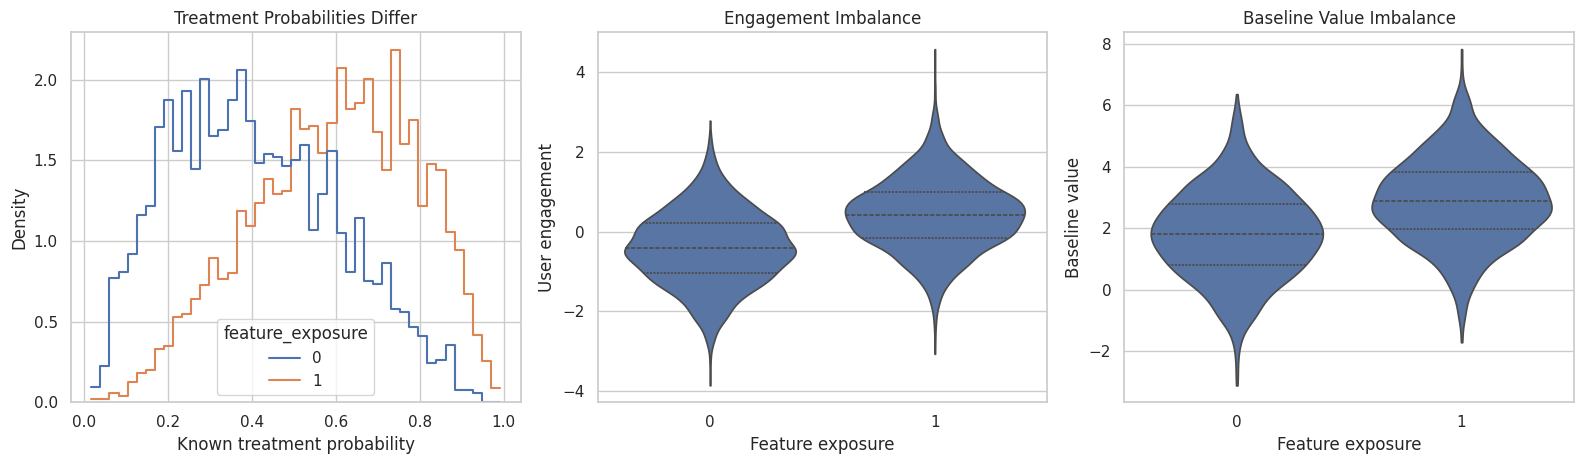

In [4]:
# Build and label the diagnostic visualization for the Confirm That Treatment Assignment Is Confounded section.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.histplot(
    data=backdoor_df,
    x="treatment_probability",
    hue="feature_exposure",
    bins=45,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Treatment Probabilities Differ")
axes[0].set_xlabel("Known treatment probability")
axes[0].set_ylabel("Density")

sns.violinplot(
    data=backdoor_df,
    x="feature_exposure",
    y="user_engagement",
    inner="quartile",
    cut=0,
    ax=axes[1],
)
axes[1].set_title("Engagement Imbalance")
axes[1].set_xlabel("Feature exposure")
axes[1].set_ylabel("User engagement")

sns.violinplot(
    data=backdoor_df,
    x="feature_exposure",
    y="baseline_value",
    inner="quartile",
    cut=0,
    ax=axes[2],
)
axes[2].set_title("Baseline Value Imbalance")
axes[2].set_xlabel("Feature exposure")
axes[2].set_ylabel("Baseline value")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_confounding_assignment_checks.png", dpi=160, bbox_inches="tight")
plt.show()


The exposed group starts out stronger on baseline dimensions. If we simply compare outcomes, we will mix the treatment effect with pre-existing differences.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




### Quantify Baseline Imbalance

A standardized mean difference compares treated and untreated groups in standard-deviation units. It is a compact way to summarize covariate imbalance before adjustment.

In [5]:
# Define reusable helpers for the Quantify Baseline Imbalance section.
def standardized_mean_difference(df, column, treatment_col="feature_exposure"):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated = df.loc[df[treatment_col] == 1, column]
    control = df.loc[df[treatment_col] == 0, column]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd

baseline_columns = ["user_engagement", "prior_sessions", "account_age_weeks", "baseline_value"]
imbalance_table = pd.DataFrame(
    [
        {
            "covariate": column,
            "treated_mean": backdoor_df.loc[backdoor_df["feature_exposure"] == 1, column].mean(),
            "control_mean": backdoor_df.loc[backdoor_df["feature_exposure"] == 0, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(backdoor_df, column),
        }
        for column in baseline_columns
    ]
).sort_values("standardized_mean_difference", key=lambda s: s.abs(), ascending=False)

imbalance_table.to_csv(TABLE_DIR / "03_baseline_imbalance_table.csv", index=False)
imbalance_table


,covariate,treated_mean,control_mean,standardized_mean_difference
0,user_engagement,0.425825,-0.407158,0.913207
3,baseline_value,2.913191,1.806659,0.775782
1,prior_sessions,3.212061,2.443362,0.433585
2,account_age_weeks,8.364014,7.737121,0.110195


Large absolute standardized mean differences tell us the treated and untreated groups are not directly comparable at baseline. This is the data symptom of confounding.



### Draw the Backdoor DAG

The graph below states the causal assumptions for the total-effect question. Baseline variables cause both treatment and outcome, so they create backdoor paths. The post-exposure activity variable is a mediator, and support ticket is a collider.

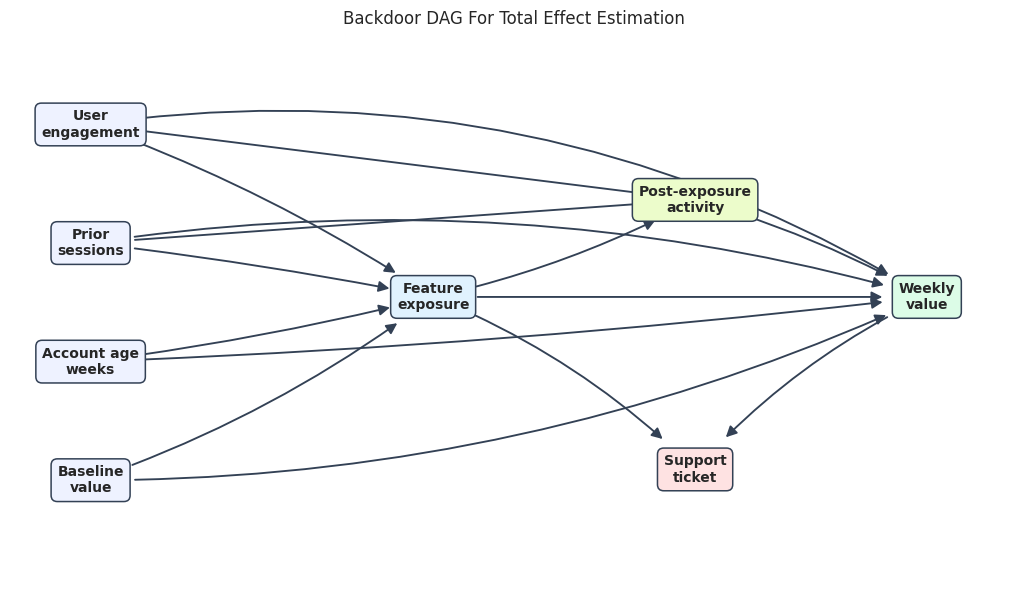

In [6]:
# Build and label the diagnostic visualization for the Draw The Backdoor DAG section.
backdoor_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "post_exposure_activity"),
    ("user_engagement", "weekly_value"),
    ("prior_sessions", "feature_exposure"),
    ("prior_sessions", "post_exposure_activity"),
    ("prior_sessions", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("baseline_value", "feature_exposure"),
    ("baseline_value", "weekly_value"),
    ("feature_exposure", "post_exposure_activity"),
    ("post_exposure_activity", "weekly_value"),
    ("feature_exposure", "weekly_value"),
    ("feature_exposure", "support_ticket"),
    ("weekly_value", "support_ticket"),
]

node_positions = {
    "user_engagement": (0.08, 0.86),
    "prior_sessions": (0.08, 0.64),
    "account_age_weeks": (0.08, 0.42),
    "baseline_value": (0.08, 0.20),
    "feature_exposure": (0.42, 0.54),
    "post_exposure_activity": (0.68, 0.72),
    "weekly_value": (0.91, 0.54),
    "support_ticket": (0.68, 0.22),
}

node_labels = {
    "user_engagement": "User\nengagement",
    "prior_sessions": "Prior\nsessions",
    "account_age_weeks": "Account age\nweeks",
    "baseline_value": "Baseline\nvalue",
    "feature_exposure": "Feature\nexposure",
    "post_exposure_activity": "Post-exposure\nactivity",
    "weekly_value": "Weekly\nvalue",
    "support_ticket": "Support\nticket",
}

node_colors = {
    "user_engagement": "#eef2ff",
    "prior_sessions": "#eef2ff",
    "account_age_weeks": "#eef2ff",
    "baseline_value": "#eef2ff",
    "feature_exposure": "#e0f2fe",
    "post_exposure_activity": "#ecfccb",
    "weekly_value": "#dcfce7",
    "support_ticket": "#fee2e2",
}

edge_radii = {
    ("user_engagement", "feature_exposure"): -0.06,
    ("prior_sessions", "feature_exposure"): -0.02,
    ("account_age_weeks", "feature_exposure"): 0.03,
    ("baseline_value", "feature_exposure"): 0.08,
    ("user_engagement", "weekly_value"): -0.18,
    ("prior_sessions", "weekly_value"): -0.11,
    ("account_age_weeks", "weekly_value"): 0.02,
    ("baseline_value", "weekly_value"): 0.11,
    ("feature_exposure", "post_exposure_activity"): 0.07,
    ("post_exposure_activity", "weekly_value"): -0.06,
    ("feature_exposure", "weekly_value"): 0.00,
    ("feature_exposure", "support_ticket"): -0.10,
    ("weekly_value", "support_ticket"): 0.10,
}

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

for source, target in backdoor_edges:
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.35,
            mutation_scale=16,
            shrinkA=32,
            shrinkB=32,
            connectionstyle=f"arc3,rad={edge_radii.get((source, target), 0.0)}",
        ),
        zorder=1,
    )

for node, (x, y) in node_positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.45", facecolor=node_colors[node], edgecolor="#334155", linewidth=1.1),
        zorder=2,
    )

ax.set_title("Backdoor DAG For Total Effect Estimation", pad=18)
fig.savefig(FIGURE_DIR / "03_backdoor_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The blue baseline variables are the adjustment variables. The green mediator and red collider are downstream of treatment, so they are not part of the adjustment set for the total effect.

### Path Reasoning

This table translates the graph into path-level decisions. A valid total-effect adjustment set blocks backdoor paths without blocking causal paths.

| path | path_type | action_for_total_effect |
| --- | --- | --- |
| feature_exposure <- user_engagement -> weekly_value | backdoor path | block by adjusting for user_engagement |
| feature_exposure <- prior_sessions -> weekly_value | backdoor path | block by adjusting for prior_sessions |
| feature_exposure <- account_age_weeks -> weekly_value | backdoor path | block by adjusting for account_age_weeks |
| feature_exposure <- baseline_value -> weekly_value | backdoor path | block by adjusting for baseline_value |
| feature_exposure -> weekly_value | direct causal path | keep open |
| feature_exposure -> post_exposure_activity -> weekly_value | mediated causal path | keep open for total effect |
| feature_exposure -> support_ticket <- weekly_value | collider path | leave closed by not conditioning on support_ticket |


The adjustment set is not a list of all useful predictors. It is the set needed to block noncausal paths while preserving the causal paths that define the total effect.

#### Naive Association versus Backdoor Adjustment

We now estimate the treatment coefficient several ways. The naive model has no controls. The valid backdoor model controls for the observed pre-treatment common causes. The bad-control models add post-treatment variables that should not be included for the total effect.

In [7]:
# Fit or evaluate the model objects used in the Naive Association Versus Backdoor Adjustment section.
formula_specs = [
    {
        "specification": "naive_no_controls",
        "formula": "weekly_value ~ feature_exposure",
        "meaning": "Association only; backdoor paths are open.",
    },
    {
        "specification": "engagement_only_partial_adjustment",
        "formula": "weekly_value ~ feature_exposure + user_engagement",
        "meaning": "Partial adjustment; some backdoor paths remain open.",
    },
    {
        "specification": "valid_backdoor_adjustment",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_sessions + account_age_weeks + baseline_value",
        "meaning": "Total-effect estimate under observed-confounding assumptions.",
    },
    {
        "specification": "bad_control_add_mediator",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_sessions + account_age_weeks + baseline_value + post_exposure_activity",
        "meaning": "Blocks the mediated path and moves toward a direct-effect-like quantity.",
    },
    {
        "specification": "bad_control_add_collider",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_sessions + account_age_weeks + baseline_value + support_ticket",
        "meaning": "Conditions on a collider and can distort the total effect.",
    },
    {
        "specification": "all_available_controls",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_sessions + account_age_weeks + baseline_value + post_exposure_activity + support_ticket",
        "meaning": "Common predictive modeling mistake: mixes confounders, mediator, and collider.",
    },
]

estimate_rows = []
for spec in formula_specs:
    fit = smf.ols(formula=spec["formula"], data=backdoor_df).fit()
    estimate = fit.params["feature_exposure"]
    ci_low, ci_high = fit.conf_int().loc["feature_exposure"].to_numpy()
    estimate_rows.append(
        {
            "specification": spec["specification"],
            "estimate": estimate,
            "ci_95_lower": ci_low,
            "ci_95_upper": ci_high,
            "distance_from_true_total": abs(estimate - truth["true_total_effect"]),
            "distance_from_true_direct": abs(estimate - truth["direct_effect"]),
            "meaning": spec["meaning"],
        }
    )

manual_estimates = pd.DataFrame(estimate_rows)
manual_estimates.to_csv(TABLE_DIR / "03_manual_backdoor_estimates.csv", index=False)
manual_estimates


,specification,estimate,ci_95_lower,ci_95_upper,distance_from_true_total,distance_from_true_direct,meaning
0,naive_no_controls,4.187805,4.056127,4.319484,1.987805,2.387805,Association only; backdoor paths are open.
1,engagement_only_partial_adjustment,2.353601,2.276337,2.430864,0.153601,0.553601,Partial adjustment; some backdoor paths remain open.
2,valid_backdoor_adjustment,2.208595,2.140507,2.276682,0.008595,0.408595,Total-effect estimate under observed-confounding assumptions.
3,bad_control_add_mediator,1.806711,1.742322,1.871100,0.393289,0.006711,Blocks the mediated path and moves toward a direct-effect-like quantity.
4,bad_control_add_collider,2.290998,2.221326,2.360670,0.090998,0.490998,Conditions on a collider and can distort the total effect.
5,all_available_controls,1.878146,1.812068,1.944223,0.321854,0.078146,"Common predictive modeling mistake: mixes confounders, mediator, and collider."


The naive estimate is much larger than the total effect because baseline differences are mixed into the treatment comparison. The valid backdoor estimate should be close to the known total effect. The mediator-adjusted estimate should move toward the direct effect because part of the pathway has been controlled away.

#### Plot the Adjustment Results

This plot compares each specification with the known total and direct effects. It makes the consequences of under-adjustment and over-adjustment easier to see.

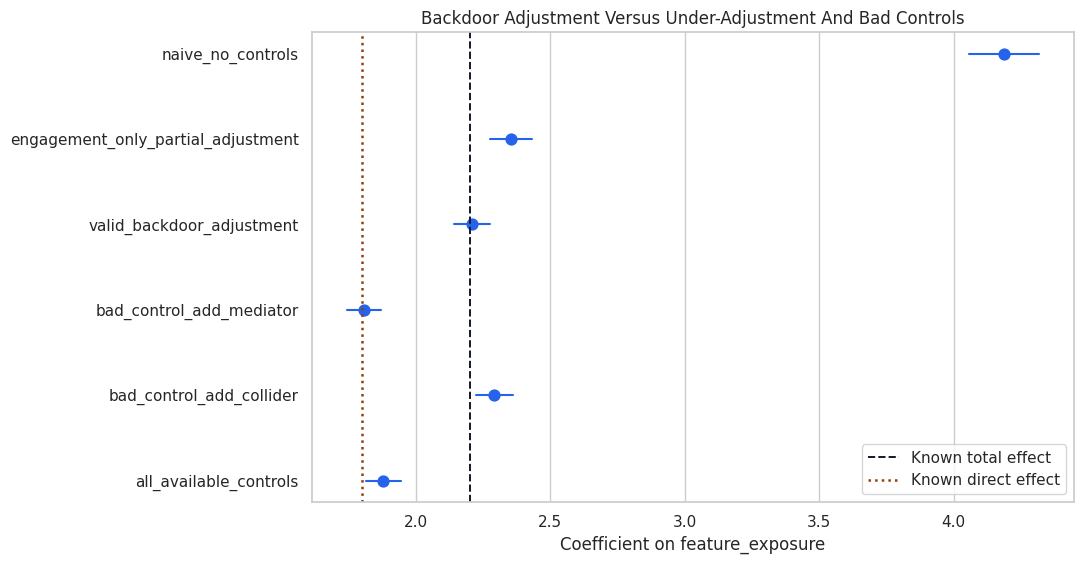

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.8))
sns.pointplot(
    data=manual_estimates,
    x="estimate",
    y="specification",
    linestyle="none",
    color="#2563eb",
    ax=ax,
)
for i, row in manual_estimates.reset_index(drop=True).iterrows():
    ax.plot([row["ci_95_lower"], row["ci_95_upper"]], [i, i], color="#2563eb", linewidth=1.5)

ax.axvline(truth["true_total_effect"], color="#111827", linestyle="--", linewidth=1.4, label="Known total effect")
ax.axvline(truth["direct_effect"], color="#92400e", linestyle=":", linewidth=1.8, label="Known direct effect")
ax.set_title("Backdoor Adjustment Versus Under-Adjustment And Bad Controls")
ax.set_xlabel("Coefficient on feature_exposure")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_backdoor_adjustment_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The valid backdoor specification is the one that targets the total effect. Adding more controls is not automatically better; controls must match the causal question.

#### Build the DoWhy Graph

Now we translate the graph into DOT syntax for DoWhy. This graph includes the confounders, the mediated pathway, and the collider, so DoWhy can reason about which variables are common causes.

In [9]:
def edges_to_dot(edges):
    """
    Idea: Convert an edge table into DOT graph syntax for DoWhy or Graphviz-style display.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    
    Returns
    -------
    str
        DOT graph string that can be passed to DoWhy or Graphviz-style renderers.
    """
    lines = ["digraph {"]
    for source, target in edges:
        lines.append(f"    {source} -> {target};")
    lines.append("}")
    return chr(10).join(lines)

backdoor_graph = edges_to_dot(backdoor_edges)
print(backdoor_graph)


digraph {
    user_engagement -> feature_exposure;
    user_engagement -> post_exposure_activity;
    user_engagement -> weekly_value;
    prior_sessions -> feature_exposure;
    prior_sessions -> post_exposure_activity;
    prior_sessions -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    baseline_value -> feature_exposure;
    baseline_value -> weekly_value;
    feature_exposure -> post_exposure_activity;
    post_exposure_activity -> weekly_value;
    feature_exposure -> weekly_value;
    feature_exposure -> support_ticket;
    weekly_value -> support_ticket;
}


This graph is the formal version of the design we drew above. DoWhy will use it to identify the effect before estimating it.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Create a DoWhy CausalModel

The code below creates the DoWhy model from data, treatment, outcome, and graph. We exclude `treatment_probability` because that is a simulation-only diagnostic rather than an observed production variable.

In [10]:
model_df = backdoor_df.drop(columns=["treatment_probability"]).copy()

backdoor_model = CausalModel(
    data=model_df,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=backdoor_graph,
)

model_metadata = pd.DataFrame(
    [
        {"component": "common_causes_reported_by_DoWhy", "value": ", ".join(backdoor_model.get_common_causes())},
        {"component": "instruments_reported_by_DoWhy", "value": ", ".join(backdoor_model.get_instruments()) or "none detected"},
        {"component": "effect_modifiers_reported_by_DoWhy", "value": ", ".join(backdoor_model.get_effect_modifiers()) or "none detected"},
    ]
)

model_metadata.to_csv(TABLE_DIR / "03_dowhy_model_metadata.csv", index=False)
model_metadata


,component,value
0,common_causes_reported_by_DoWhy,"user_engagement, prior_sessions, account_age_weeks, baseline_value"
1,instruments_reported_by_DoWhy,none detected
2,effect_modifiers_reported_by_DoWhy,none detected


DoWhy reports the pre-treatment common causes. The mediator and collider are not listed as common causes, which is what we want for the total-effect question.

#### Identify the Backdoor Estimand

Identification asks whether the causal effect can be expressed from observed data under the graph assumptions. For this graph, DoWhy should identify a backdoor-adjustment estimand.

In [11]:
identified_estimand = backdoor_model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|user_engagement,prior_sessions,account_age_w ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                      
↪ eeks,baseline_value])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,user_engagement,prior_sessions,account_age_weeks,baseline_value,U) = P(weekly_value|feature_exposure,user_engagement,prior_sessions,account_age_weeks,baseline_value)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



The printed estimand states the key assumption: after conditioning on the observed common causes, there is no remaining unobserved common cause of treatment and outcome. That assumption is not a statistical output; it is a design claim.

#### Estimate the Backdoor Effect with DoWhy

Now we estimate the identified estimand using DoWhy's linear-regression estimator. In this example data, the graph is correct and all common causes are observed, so the estimate should be near the known total effect.

In [12]:
dowhy_linear_estimate = backdoor_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print(dowhy_linear_estimate)
print(f"DoWhy backdoor estimate: {float(dowhy_linear_estimate.value):.4f}")
print(f"Known total effect: {truth['true_total_effect']:.4f}")
print(f"Known direct effect: {truth['direct_effect']:.4f}")

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|user_engagement,prior_sessions,account_age_w ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                      
↪ eeks,baseline_value])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,user_engagement,prior_sessions,account_age_weeks,baseline_value,U) = P(weekly_value|feature_exposure,user_engagement,prior_sessions,account_age_weeks,baseline_value)

## Realized estimand
b: weekly_value~feature_exposure+user_engagement+prior_sessions+account_age_weeks+baseline_value
Target units: ate

## Estimate
Mean value: 2.2085947187752444

DoWhy backdoor estimate: 2.2086
Known total effect: 2.2000

The DoWhy estimate should align with the valid manual backdoor regression because they are using the same adjustment logic. The value is near the total effect, not the direct effect.



#### Compare Manual and DoWhy Estimates

This table places the manual estimates and DoWhy estimate together. It is a useful sanity check because DoWhy's estimator should match the ordinary adjusted regression when the same linear specification is used.

In [13]:
dowhy_comparison = pd.concat(
    [
        manual_estimates[["specification", "estimate", "distance_from_true_total", "meaning"]],
        pd.DataFrame(
            [
                {
                    "specification": "dowhy_backdoor_linear_regression",
                    "estimate": float(dowhy_linear_estimate.value),
                    "distance_from_true_total": abs(float(dowhy_linear_estimate.value) - truth["true_total_effect"]),
                    "meaning": "DoWhy estimate after graph-based identification.",
                }
            ]
        ),
    ],
    ignore_index=True,
)

dowhy_comparison.to_csv(TABLE_DIR / "03_manual_vs_dowhy_estimates.csv", index=False)
dowhy_comparison


,specification,estimate,distance_from_true_total,meaning
0,naive_no_controls,4.187805,1.987805,Association only; backdoor paths are open.
1,engagement_only_partial_adjustment,2.353601,0.153601,Partial adjustment; some backdoor paths remain open.
2,valid_backdoor_adjustment,2.208595,0.008595,Total-effect estimate under observed-confounding assumptions.
3,bad_control_add_mediator,1.806711,0.393289,Blocks the mediated path and moves toward a direct-effect-like quantity.
4,bad_control_add_collider,2.290998,0.090998,Conditions on a collider and can distort the total effect.
5,all_available_controls,1.878146,0.321854,"Common predictive modeling mistake: mixes confounders, mediator, and collider."
6,dowhy_backdoor_linear_regression,2.208595,0.008595,DoWhy estimate after graph-based identification.


The main lesson is not that DoWhy gives a different regression coefficient. The lesson is that DoWhy wraps the coefficient in a graph, an estimand, and a set of assumptions.

#### Refute the Backdoor Estimate

Refuters are stress tests. They cannot prove the causal effect is correct. They help catch estimates that behave strangely under simple perturbations.

In [14]:
# Define reusable helpers for the Refute The Backdoor Estimate section.
def scalar_or_nan(value):
    """
    Idea: Convert a one-element result to a float and use NaN when the value is unavailable.
    
    Parameters
    ----------
    value : object
        Numeric value being converted, formatted, or compared.
    
    Returns
    -------
    float
        Scalar float extracted from the input, or NaN when extraction is not possible.
    """
    try:
        return float(np.asarray(value).reshape(-1)[0])
    except Exception:
        return np.nan

refuter_specs = [
    (
        "placebo_treatment_refuter",
        {
            "method_name": "placebo_treatment_refuter",
            "placebo_type": "permute",
            "num_simulations": 20,
        },
        "A fake treatment should not reproduce the original effect.",
    ),
    (
        "random_common_cause",
        {
            "method_name": "random_common_cause",
            "num_simulations": 20,
        },
        "Adding a random irrelevant common cause should not materially change the effect.",
    ),
    (
        "data_subset_refuter",
        {
            "method_name": "data_subset_refuter",
            "subset_fraction": 0.80,
            "num_simulations": 20,
        },
        "Random subsets should produce estimates in the same neighborhood.",
    ),
]

refuter_rows = []
for label, kwargs, expected_behavior in refuter_specs:
    result = backdoor_model.refute_estimate(identified_estimand, dowhy_linear_estimate, **kwargs)
    payload = getattr(result, "refutation_result", None)
    p_value = np.nan
    if isinstance(payload, dict):
        p_value = scalar_or_nan(payload.get("p_value"))
    new_effect = scalar_or_nan(result.new_effect)
    estimated_effect = scalar_or_nan(result.estimated_effect)
    refuter_rows.append(
        {
            "refuter": label,
            "estimated_effect": estimated_effect,
            "new_effect": new_effect,
            "effect_shift": new_effect - estimated_effect,
            "p_value": p_value,
            "expected_behavior": expected_behavior,
        }
    )

refuter_summary = pd.DataFrame(refuter_rows)
refuter_summary.to_csv(TABLE_DIR / "03_refuter_summary.csv", index=False)
refuter_summary


,refuter,estimated_effect,new_effect,effect_shift,p_value,expected_behavior
0,placebo_treatment_refuter,2.208595,0.009687,-2.198908,0.423699,A fake treatment should not reproduce the original effect.
1,random_common_cause,2.208595,2.208533,-0.000062,0.450211,Adding a random irrelevant common cause should not materially change the effect.
2,data_subset_refuter,2.208595,2.212724,0.004129,0.389276,Random subsets should produce estimates in the same neighborhood.


The placebo result should move toward zero, while the random-common-cause and subset checks should stay close to the original estimate. These are basic checks, not a replacement for thinking carefully about unobserved confounding.

#### Visualize Refuter Results

This plot shows the original estimate next to the refuter-generated effects.

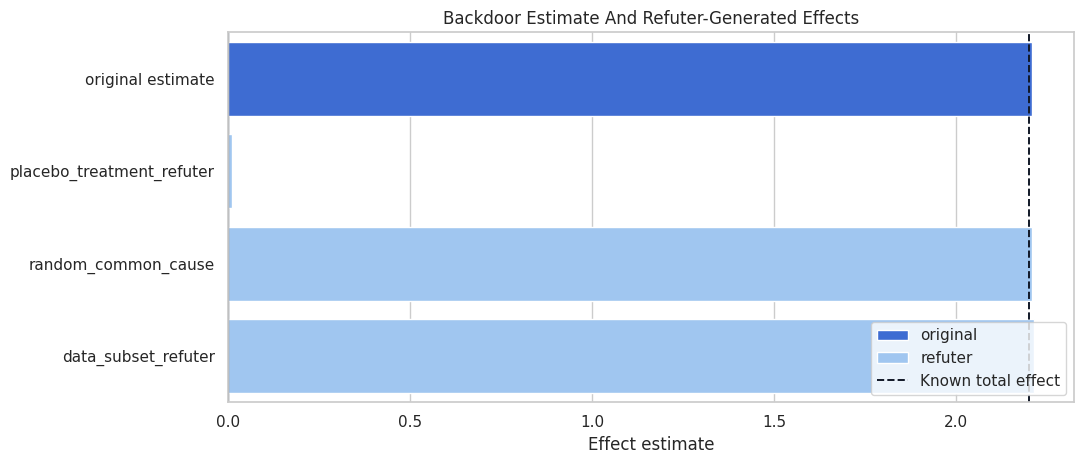

In [15]:
# Build and label the diagnostic visualization for the Visualize Refuter Results section.
refuter_plot_df = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "label": "original estimate",
                    "effect": float(dowhy_linear_estimate.value),
                    "type": "original",
                }
            ]
        ),
        refuter_summary.assign(label=refuter_summary["refuter"], effect=refuter_summary["new_effect"], type="refuter")[
            ["label", "effect", "type"]
        ],
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(
    data=refuter_plot_df,
    x="effect",
    y="label",
    hue="type",
    dodge=False,
    palette={"original": "#2563eb", "refuter": "#93c5fd"},
    ax=ax,
)
ax.axvline(0, color="#6b7280", linewidth=1)
ax.axvline(truth["true_total_effect"], color="#111827", linestyle="--", linewidth=1.4, label="Known total effect")
ax.set_title("Backdoor Estimate And Refuter-Generated Effects")
ax.set_xlabel("Effect estimate")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_refuter_results.png", dpi=160, bbox_inches="tight")
plt.show()


The refuter plot should show a clear separation between the original effect and the placebo effect. Stable subset and random-common-cause results are reassuring, but they do not test every possible source of bias.



#### What If a Confounder is Unobserved?

Backdoor adjustment only works if the important common causes are observed and measured well enough. This section creates a second dataset with a latent confounder. We will compare naive adjustment, observed-only adjustment, and an oracle adjustment that includes the latent variable.

The oracle model is not available in real work. It is included only to show what unobserved confounding can do.

In [16]:
# Define reusable helpers for the What If A Confounder Is Unobserved? section.
def make_hidden_confounding_data(n=5_000, seed=91):
    """
    Idea: Construct the hidden confounding data used in the What If A Confounder Is Unobserved? section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_effect.
    """
    local_rng = np.random.default_rng(seed)
    latent_motivation = local_rng.normal(loc=0.0, scale=1.0, size=n)
    proxy_engagement = 0.60 * latent_motivation + local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_sessions = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.20 * proxy_engagement), size=n),
        0,
        25,
    )

    treatment_logit = -0.40 + 0.70 * proxy_engagement + 0.050 * prior_sessions + 1.00 * latent_motivation
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)

    true_effect = 1.50
    weekly_value = (
        3.0
        + true_effect * feature_exposure
        + 0.90 * proxy_engagement
        + 0.050 * prior_sessions
        + 1.40 * latent_motivation
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "proxy_engagement": proxy_engagement,
            "prior_sessions": prior_sessions,
            "latent_motivation": latent_motivation,
            "treatment_probability": treatment_probability,
        }
    )
    return df, true_effect

hidden_df, hidden_true_effect = make_hidden_confounding_data()

hidden_estimates = []
for specification, formula, meaning in [
    ("naive_no_controls", "weekly_value ~ feature_exposure", "No confounding adjustment."),
    (
        "observed_controls_only",
        "weekly_value ~ feature_exposure + proxy_engagement + prior_sessions",
        "Uses observed proxy variables but omits latent motivation.",
    ),
    (
        "oracle_includes_latent_confounder",
        "weekly_value ~ feature_exposure + proxy_engagement + prior_sessions + latent_motivation",
        "Only possible in simulation; shows what would happen if the latent confounder were observed.",
    ),
]:
    fit = smf.ols(formula=formula, data=hidden_df).fit()
    estimate = fit.params["feature_exposure"]
    ci_low, ci_high = fit.conf_int().loc["feature_exposure"].to_numpy()
    hidden_estimates.append(
        {
            "specification": specification,
            "estimate": estimate,
            "ci_95_lower": ci_low,
            "ci_95_upper": ci_high,
            "distance_from_true_effect": abs(estimate - hidden_true_effect),
            "meaning": meaning,
        }
    )

hidden_confounding_results = pd.DataFrame(hidden_estimates)
hidden_confounding_results.to_csv(TABLE_DIR / "03_hidden_confounding_results.csv", index=False)
hidden_confounding_results


,specification,estimate,ci_95_lower,ci_95_upper,distance_from_true_effect,meaning
0,naive_no_controls,3.896750,3.780466,4.013034,2.396750,No confounding adjustment.
1,observed_controls_only,2.360954,2.267349,2.454560,0.860954,Uses observed proxy variables but omits latent motivation.
2,oracle_includes_latent_confounder,1.470193,1.404429,1.535957,0.029807,Only possible in simulation; shows what would happen if the latent confounder were observed.


Observed controls help, but they do not fully remove bias when an important common cause is unobserved. The oracle row shows why measurement matters: a valid adjustment set is more than a graph idea; it requires actual columns that measure the relevant causes.



#### Visualize Hidden Confounding

This plot compares the hidden-confounding estimates to the true effect from the simulation.

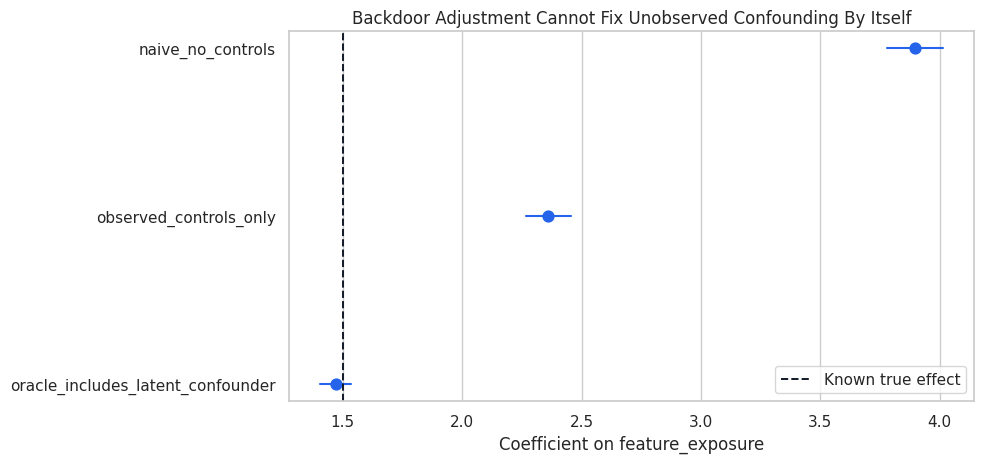

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.pointplot(
    data=hidden_confounding_results,
    x="estimate",
    y="specification",
    linestyle="none",
    color="#2563eb",
    ax=ax,
)
for i, row in hidden_confounding_results.reset_index(drop=True).iterrows():
    ax.plot([row["ci_95_lower"], row["ci_95_upper"]], [i, i], color="#2563eb", linewidth=1.5)

ax.axvline(hidden_true_effect, color="#111827", linestyle="--", linewidth=1.4, label="Known true effect")
ax.set_title("Backdoor Adjustment Cannot Fix Unobserved Confounding By Itself")
ax.set_xlabel("Coefficient on feature_exposure")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_hidden_confounding_results.png", dpi=160, bbox_inches="tight")
plt.show()


The observed-only model remains biased because the true common cause is only partially measured. This is why causal reports should say `under observed-confounding assumptions` and avoid treating adjustment as automatic proof.



#### Assumption Register

A backdoor analysis should document its assumptions plainly. This table turns the graph into reviewable claims.

| assumption | why_it_matters | diagnostic_or_response |
| --- | --- | --- |
| All major common causes of exposure and weekly value are measured. | Backdoor adjustment fails if important common causes are missing. | Use domain review, pre-treatment covariate audits, sensitivity checks, and negative controls where possible. |
| Adjustment variables are pre-treatment. | Post-treatment controls can block causal pathways or open collider paths. | Create a variable timing table before modeling. |
| The chosen covariates block backdoor paths without blocking the total-effect pathway. | The estimand should match the causal question. | Write path reasoning before estimating the effect. |
| There is adequate overlap across treatment groups after adjustment. | Adjustment becomes unstable when comparable controls or treated units are absent. | Inspect propensity overlap and common support in a dedicated weighting/overlap analysis. |
| The outcome model is adequate for the estimator being used. | A valid estimand can still be estimated poorly by a misspecified model. | Compare estimators and inspect residual/model diagnostics. |


This table is the honest part of the analysis. It tells a reader where the result is strongest and where judgment or additional diagnostics are still needed.



#### Final Backdoor Checklist

This checklist is a reusable workflow for backdoor adjustment in future notebooks.

| step | question_to_answer |
| --- | --- |
| Define treatment and outcome | What intervention and outcome window are being compared? |
| Mark timing | Which variables are definitely measured before treatment? |
| Draw common causes | Which pre-treatment variables plausibly cause both treatment and outcome? |
| Avoid bad controls | Are any proposed controls mediators, colliders, or descendants of treatment? |
| Check baseline imbalance | How different are treated and untreated users before treatment? |
| Identify with DoWhy | What adjustment set and assumptions does DoWhy print? |
| Estimate and compare | How do naive, partial, valid, and bad-control estimates differ? |
| Run refuters | Does the estimate behave sensibly under placebo and perturbation checks? |
| State limitations | Which unobserved confounders or measurement gaps could still bias the result? |


The checklist makes backdoor adjustment less mysterious. The hard part is not calling an estimator; the hard part is defending the adjustment set.

The practical value is that the method becomes a repeatable workflow rather than a sequence of disconnected package calls.
<!-- result-implication-expanded -->


#### Final Causal Summary

This final table shows how to summarize the tutorial result without overclaiming.

In [18]:
# Save the artifacts produced by the Final Causal Summary section.
final_summary = pd.DataFrame(
    [
        {
            "item": "Causal question",
            "summary": "Total average effect of feature exposure on weekly value.",
        },
        {
            "item": "Valid adjustment variables in this example graph",
            "summary": "user_engagement, prior_sessions, account_age_weeks, and baseline_value.",
        },
        {
            "item": "Known total effect",
            "summary": f"{truth['true_total_effect']:.3f}",
        },
        {
            "item": "DoWhy backdoor estimate",
            "summary": f"{float(dowhy_linear_estimate.value):.3f}",
        },
        {
            "item": "What the naive estimate does wrong",
            "summary": "It mixes treatment effect with baseline differences between exposed and unexposed users.",
        },
        {
            "item": "What mediator adjustment does wrong for total effect",
            "summary": "It blocks part of the causal pathway and moves toward a direct-effect-like quantity.",
        },
        {
            "item": "What collider adjustment can do wrong",
            "summary": "It can open a noncausal path between treatment and outcome.",
        },
        {
            "item": "Main limitation",
            "summary": "Backdoor adjustment depends on measured common causes; unobserved confounding can remain.",
        },
    ]
)

final_summary.to_csv(TABLE_DIR / "03_final_backdoor_summary.csv", index=False)
final_summary


,item,summary
0,Causal question,Total average effect of feature exposure on weekly value.
1,Valid adjustment variables in this example graph,"user_engagement, prior_sessions, account_age_weeks, and baseline_value."
2,Known total effect,2.200
3,DoWhy backdoor estimate,2.209
4,What the naive estimate does wrong,It mixes treatment effect with baseline differences between exposed and unexposed users.
5,What mediator adjustment does wrong for total effect,It blocks part of the causal pathway and moves toward a direct-effect-like quantity.
6,What collider adjustment can do wrong,It can open a noncausal path between treatment and outcome.
7,Main limitation,Backdoor adjustment depends on measured common causes; unobserved confounding can remain.


The final summary names both the estimate and the assumptions. That is the habit to preserve in all observational causal analyses.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Student Exercises

Try these after running the notebook:

1. Remove `baseline_value` from the valid adjustment formula and see how much bias returns.
2. Increase the effect of `user_engagement` in the treatment assignment equation and watch the naive estimate move farther from the truth.
3. Increase the effect of `post_exposure_activity` on `weekly_value` and see how much mediator adjustment changes the estimate.
4. Change the support-ticket equation and observe whether collider adjustment becomes more or less damaging.
5. Rewrite the assumption register for a real dataset you know.

#### Closing Notes

Backdoor adjustment is powerful when its assumptions are credible: the common causes are observed, pre-treatment, and sufficient to block noncausal paths. It is fragile when analysts under-adjust, over-adjust, condition on colliders, or miss important common causes.

The next tutorial will compare common estimators for the same identified estimand: regression, matching, stratification, and propensity-score methods.